In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import exposure # Para CLAHE en color
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, closing, disk
from skimage.measure import label, regionprops

In [14]:
params_set8 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 220,        # Muy bajo
    "dark_thresh_factor": 1.15,  # Bastante sensible a oscuros
    "low_sat_thresh": 100,       # Muy alto (muy sensible a desaturación)
    "very_dark_val_thresh": 100, # Muy alto (muy sensible a valores bajos/oscuridad)
    "line_threshold": 45,        # Moderado, el foco es el color
    "opening_disk_radius": 1,
    "closing_disk_radius": 5,    # Conectar bien las regiones de color
    "min_size_noise": 30,
    "crack_lower_intensity_bound":70 # Pixels darker than this are excluded from dark_mask (e.g. pure black
}
param_sets_to_test = [
    {"name": "", **params_set8}
]

In [27]:
def show_images(images, titles=None, cmap_list=None):
    """Helper function to display multiple images"""
    n_images = len(images)
    if titles is None:
        titles = ['Image %d' % (i+1) for i in range(n_images)]
    if cmap_list is None:
        cmap_list = [None] * n_images

    # Ajustar el tamaño de la figura dinámicamente
    cols = min(n_images, 4) # Mostrar un máximo de 4 imágenes por fila
    rows = (n_images + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows)) # Ajustar el tamaño por imagen

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        if cmap_list[i] == 'gray':
            plt.imshow(images[i], cmap='gray')
        else:
            # Asegurar que las imágenes BGR se muestren correctamente
            if len(images[i].shape) == 3 and images[i].shape[2] == 3:
                 plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
            else: # Para imágenes en escala de grises o ya en RGB
                 plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def detect_damage_02(img_bgr,
                  clahe_clip_limit=1.5,
                  fissure_opening_radius=1,
                  fissure_closing_radius=3,
                  fissure_min_area=50,
                  brown_lower = np.array([20, 30, 30]),
                  brown_upper = np.array([30, 255, 150]), # Marrón oscuro
                  ):
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Brown Color Filtering for Crack Detection ---
    # Define brown color range in HSV (this can be further tuned)
    brown_lower_1 = brown_lower
    brown_upper_1 = brown_upper

    hsv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    brown_mask = cv2.inRange(hsv_img, brown_lower_1, brown_upper_1)

    fissure_candidate_mask = brown_mask.copy()

    # --- 3. Morphological Operations ---
    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- 4. Final Output ---
    final_mask = fissure_mask_refined

    return final_mask


In [29]:
def calculate_metrics(predicted_mask, ground_truth_mask, epsilon=1e-6):
    """Calculates Intersection over Union (IoU), Dice Coefficient, Precision, Recall, and Accuracy."""
    predicted_mask_bool = predicted_mask.astype(bool)
    ground_truth_mask_bool = ground_truth_mask.astype(bool)

    tp = np.sum(np.logical_and(predicted_mask_bool, ground_truth_mask_bool))
    fp = np.sum(np.logical_and(predicted_mask_bool, np.logical_not(ground_truth_mask_bool)))
    fn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), ground_truth_mask_bool))
    tn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), np.logical_not(ground_truth_mask_bool)))

    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    precision = (tp + epsilon) / (tp + fp + epsilon)
    recall = (tp + epsilon) / (tp + fn + epsilon)
    accuracy = (tp + tn + epsilon) / (tp + fp + fn + tn + epsilon)

    return {
        "iou": iou, "dice": dice, "precision": precision, "recall": recall,
        "accuracy": accuracy, "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }

In [33]:
param_sets_cracks = {
        "clahe_clip_limit": 0.2,
        "line_threshold": 50,
        "opening_radius": 1.85,
        "closing_radius": 1.85,
        "min_fissure_area": 30
    }


def detect_thin_cracks(
    img_bgr,
    clahe_clip_limit=0.3,
    line_threshold=30,              # Lower threshold to catch faint cracks
    opening_radius=1,               # Small radius to preserve thin lines
    closing_radius=2,
    min_fissure_area=10,            # Keep small, thin objects
    min_aspect_ratio=1.5            # Only keep elongated objects (length/width > 2.5)
):
    # 1. Enhance local contrast
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # 2. Edge detection (Sobel)
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    edge_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)
    edge_response = cv2.normalize(edge_response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 3. Threshold to binarize edges
    _, edge_mask = cv2.threshold(edge_response, line_threshold, 255, cv2.THRESH_BINARY)

    # 4. Morphological cleaning (preserve thin lines)
    se_open = disk(opening_radius)
    se_close = disk(closing_radius)
    mask_open = opening(edge_mask, se_open)
    mask_close = closing(mask_open, se_close)

    # 5. Remove small objects, keep only elongated ones
    mask_bool = mask_close.astype(bool)
    label_img = label(mask_bool)
    props = regionprops(label_img)
    final_mask = np.zeros_like(mask_close, dtype=np.uint8)
    for prop in props:
        if prop.area >= min_fissure_area:
            # Aspect ratio: major_axis_length / minor_axis_length
            if prop.minor_axis_length > 0:
                aspect = prop.major_axis_length / prop.minor_axis_length
            else:
                aspect = 0
            if aspect >= min_aspect_ratio:
                final_mask[label_img == prop.label] = 255

    return final_mask, grayscale, edge_response, edge_mask

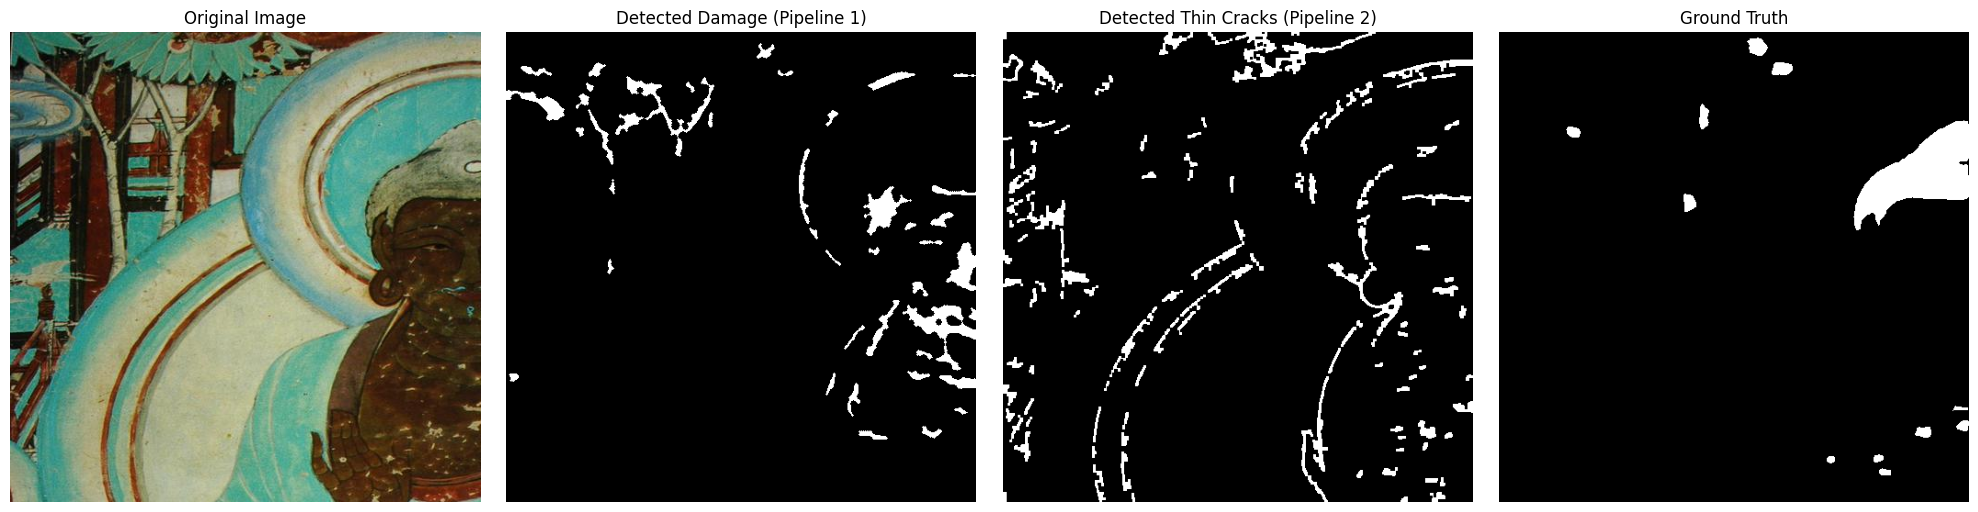

Metrics for 000076.png: {'iou': np.float64(0.07681427488429908), 'dice': np.float64(0.14266949585012279), 'precision': np.float64(0.13072863631786608), 'recall': np.float64(0.1570110086559534), 'accuracy': np.float64(0.9352645874025907), 'tp': np.int64(1412), 'fp': np.int64(9389), 'fn': np.int64(7581), 'tn': np.int64(243762)}


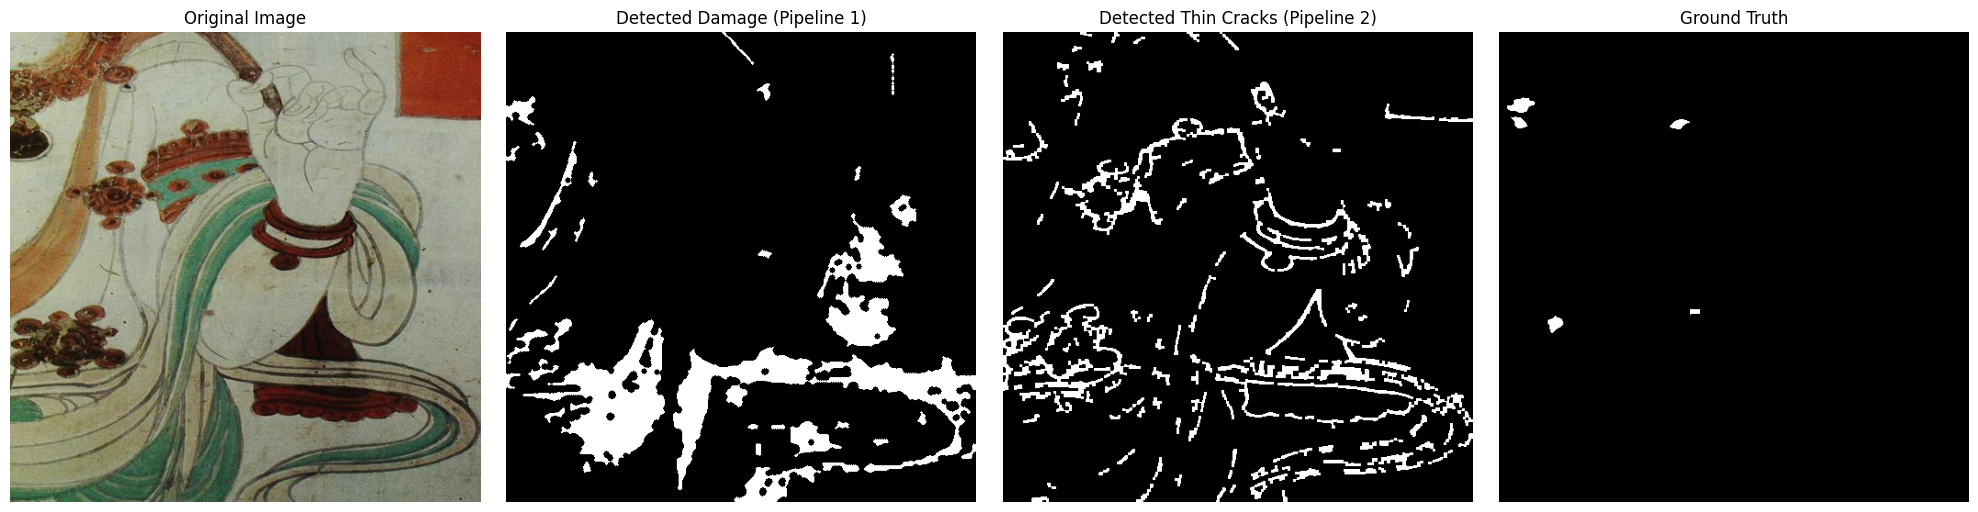

Metrics for 000103.png: {'iou': np.float64(0.01235536952693891), 'dice': np.float64(0.024409154896924183), 'precision': np.float64(0.012506621181434094), 'recall': np.float64(0.5053507734775853), 'accuracy': np.float64(0.8704032897954163), 'tp': np.int64(425), 'fp': np.int64(33557), 'fn': np.int64(416), 'tn': np.int64(227746)}


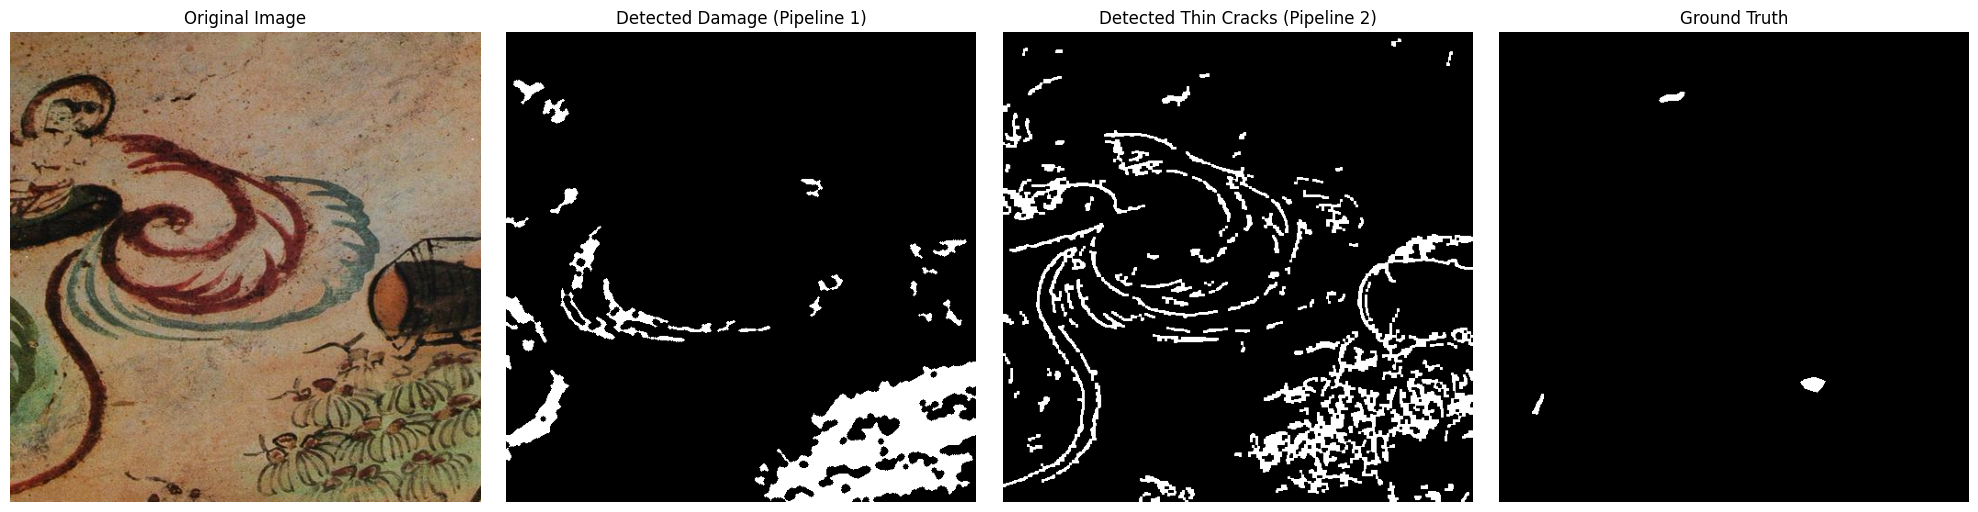

Metrics for 000000.png: {'iou': np.float64(0.004255639701568349), 'dice': np.float64(0.008475211917480116), 'precision': np.float64(0.00433731243985962), 'recall': np.float64(0.18433931617562918), 'accuracy': np.float64(0.8991394042972598), 'tp': np.int64(113), 'fp': np.int64(25940), 'fn': np.int64(500), 'tn': np.int64(235591)}


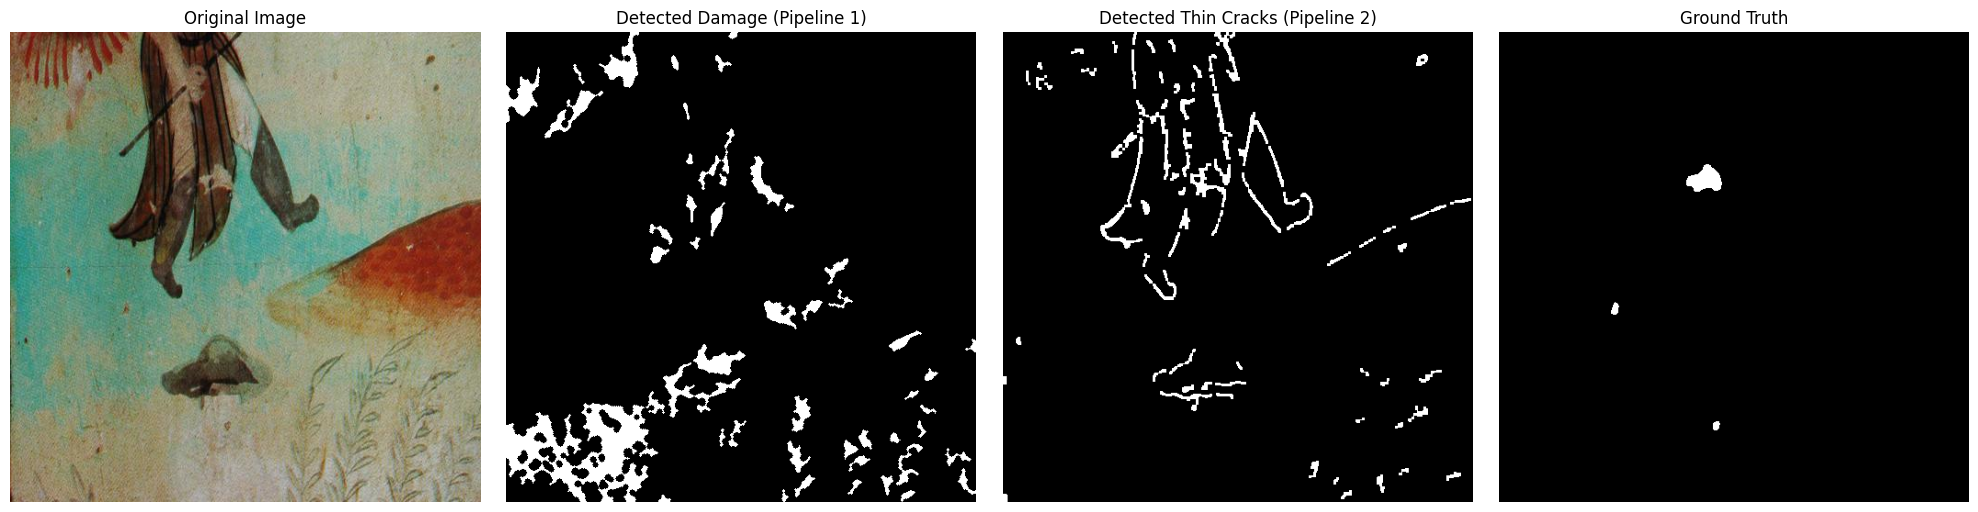

Metrics for 000106.png: {'iou': np.float64(0.011404414343439787), 'dice': np.float64(0.022551640387725315), 'precision': np.float64(0.011788617936392855), 'recall': np.float64(0.2592178779226616), 'accuracy': np.float64(0.9232826232913083), 'tp': np.int64(232), 'fp': np.int64(19448), 'fn': np.int64(663), 'tn': np.int64(241801)}


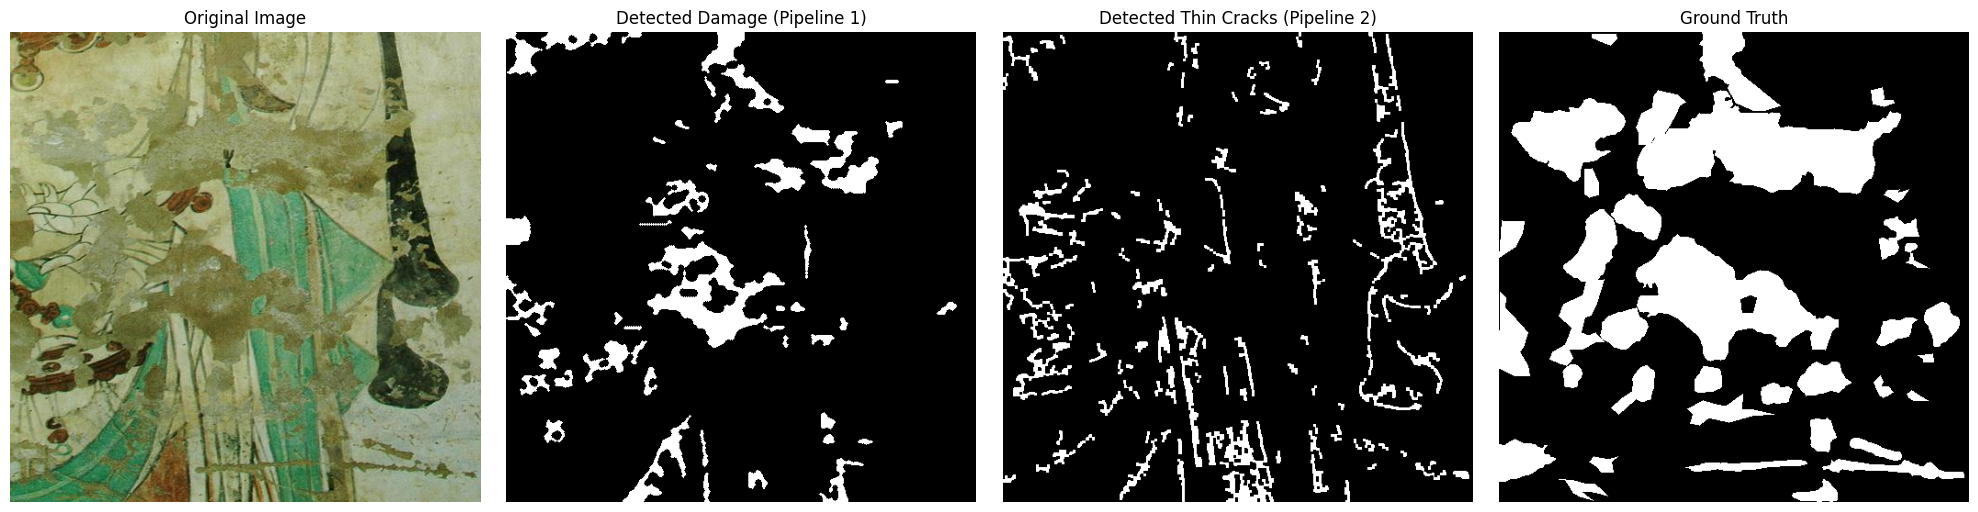

Metrics for 000087.png: {'iou': np.float64(0.1835840532322562), 'dice': np.float64(0.31021717929812376), 'precision': np.float64(0.6279346211153498), 'recall': np.float64(0.20599130968739918), 'accuracy': np.float64(0.7490806579599416), 'tp': np.int64(14791), 'fp': np.int64(8764), 'fn': np.int64(57013), 'tn': np.int64(181576)}


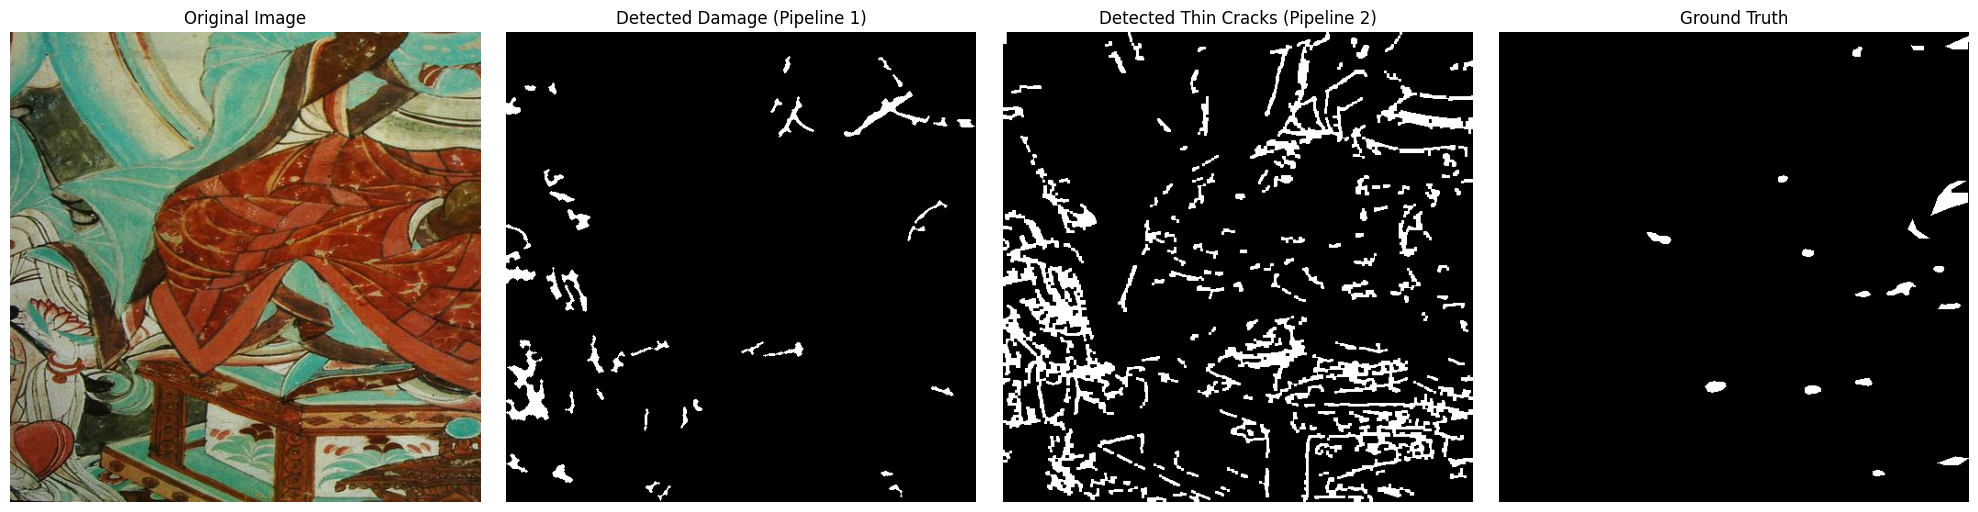

Metrics for 000078.png: {'iou': np.float64(0.009156962375917491), 'dice': np.float64(0.01814774642290682), 'precision': np.float64(0.012653005224501029), 'recall': np.float64(0.032078103545300524), 'accuracy': np.float64(0.962024688720848), 'tp': np.int64(92), 'fp': np.int64(7179), 'fn': np.int64(2776), 'tn': np.int64(252097)}


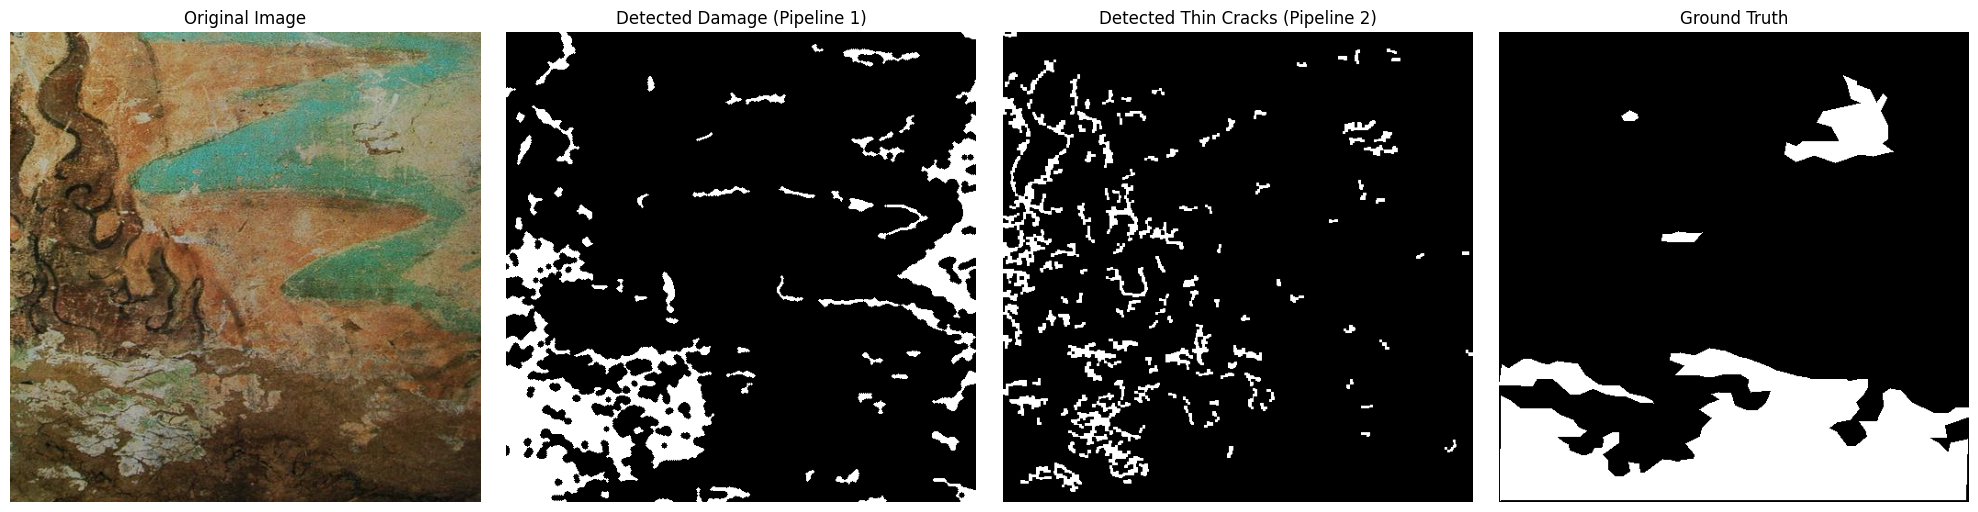

Metrics for 000091.png: {'iou': np.float64(0.11591699514124837), 'dice': np.float64(0.20775200241839464), 'precision': np.float64(0.2551871985489833), 'recall': np.float64(0.1751874693535779), 'accuracy': np.float64(0.7090873718272817), 'tp': np.int64(9999), 'fp': np.int64(29184), 'fn': np.int64(47077), 'tn': np.int64(175884)}


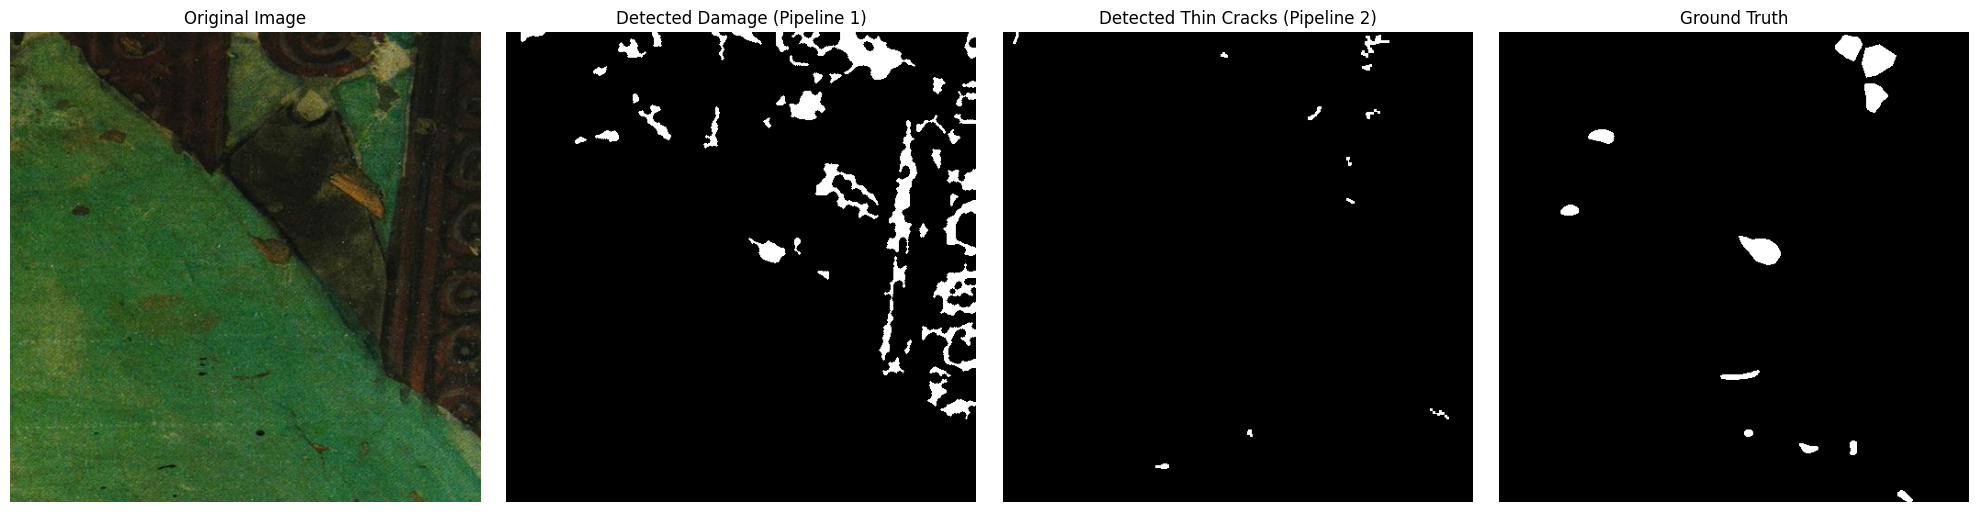

Metrics for 000021.png: {'iou': np.float64(0.11985739351933351), 'dice': np.float64(0.2140583152653465), 'precision': np.float64(0.1354653022618826), 'recall': np.float64(0.5098700049326264), 'accuracy': np.float64(0.9406700134279607), 'tp': np.int64(2118), 'fp': np.int64(13517), 'fn': np.int64(2036), 'tn': np.int64(244473)}


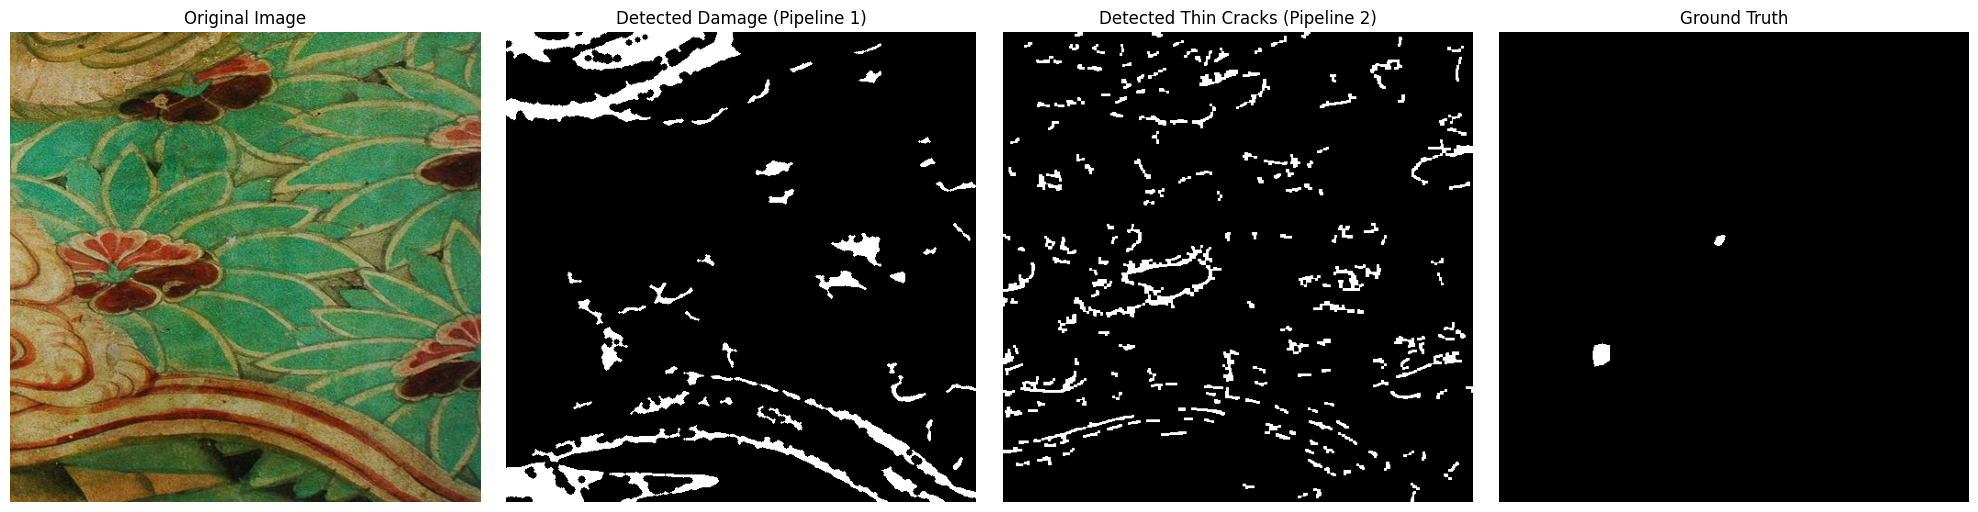

Metrics for 000123.png: {'iou': np.float64(0.011702817100152372), 'dice': np.float64(0.023134890767779394), 'precision': np.float64(0.011790007334698337), 'recall': np.float64(0.6127744518707097), 'accuracy': np.float64(0.9011001586917835), 'tp': np.int64(307), 'fp': np.int64(25732), 'fn': np.int64(194), 'tn': np.int64(235911)}


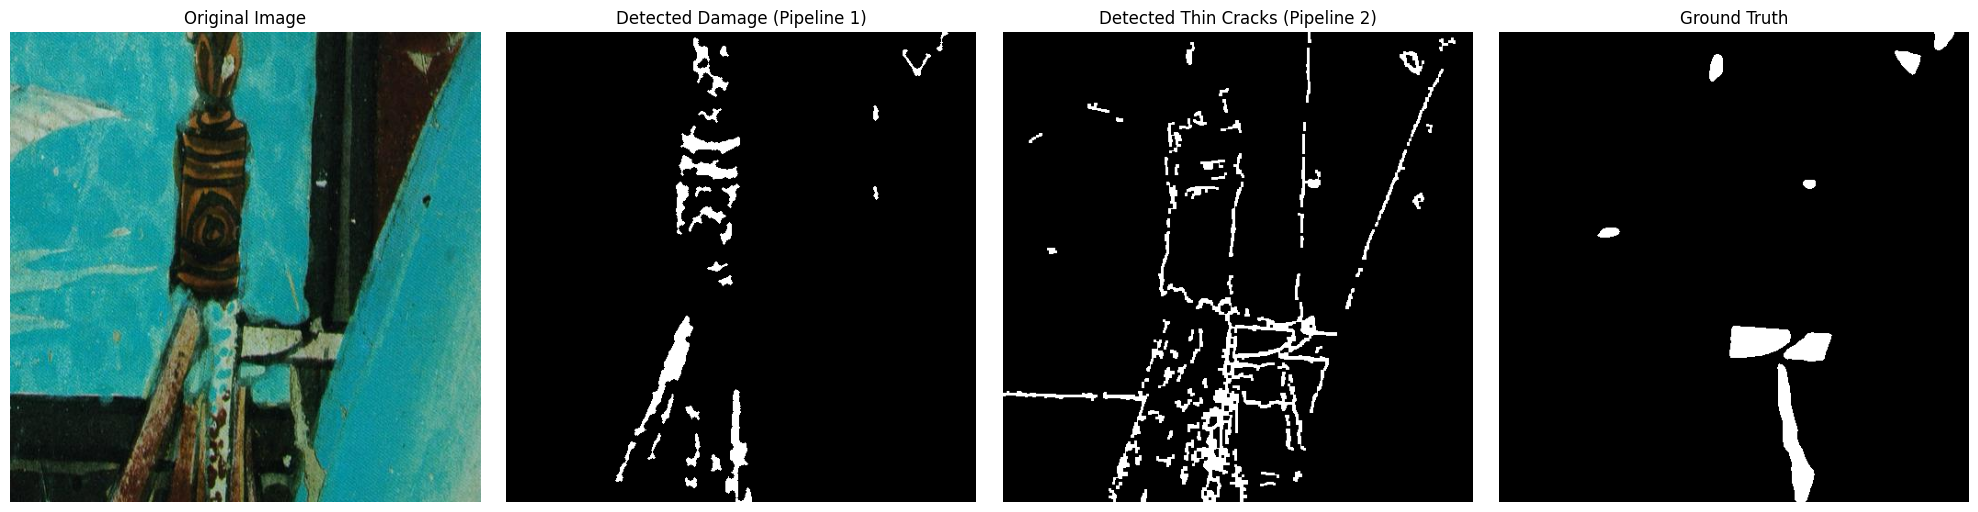

Metrics for 000055.png: {'iou': np.float64(0.015509651268844588), 'dice': np.float64(0.030545551618611073), 'precision': np.float64(0.027875837002084496), 'recall': np.float64(0.033780793769909896), 'accuracy': np.float64(0.9445495605470865), 'tp': np.int64(229), 'fp': np.int64(7986), 'fn': np.int64(6550), 'tn': np.int64(247379)}


In [35]:
# --- Run in 10 random images and show the results and comparation with label ---
images_folder = 'dataset_con_filtro/img'
labels_folder = 'dataset_con_filtro/img_filter'

image_files = [f for f in os.listdir(images_folder) if f.endswith('.jpg') or f.endswith('.png')]
np.random.seed(42)  # For reproducibility
selected_files = np.random.choice(image_files, size=10, replace=False)

params = {
    "clahe_clip_limit": 2.0,
}

for file_name in selected_files:
    img_path = os.path.join(images_folder, file_name)
    label_path = os.path.join(labels_folder, file_name.replace('.jpg', '.png').replace('.png', '.png'))

    img_bgr = cv2.imread(img_path)
    label_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

    if img_bgr is None or label_mask is None:
        print(f"Error loading image or label for {file_name}. Skipping.")
        continue

    # Detect damage
    final_mask = detect_damage_02(
        img_bgr.copy(), **params)
    
    # Detect thin cracks
    thin_crack_mask, grayscale, edge_response, edge_mask = detect_thin_cracks(
        img_bgr.copy(), **param_sets_cracks)

    # Calculate metrics
    metrics = calculate_metrics(final_mask, label_mask)

    # Show results
    show_images([img_bgr, final_mask, thin_crack_mask, label_mask],
                titles=["Original Image", "Detected Damage (Pipeline 1)", "Detected Thin Cracks (Pipeline 2)", "Ground Truth"],
                cmap_list=['bgr', 'gray', 'gray', 'gray'])
    

    print(f"Metrics for {file_name}: {metrics}")